# 2026-10-10: NGC4654 blind SF asymmetry and external-control enhancement

Follow-up to [Rigorous SF Enhancement Detection](https://chatgpt.com/c/6ac9d761-db10-83ec-9047-da278b600abd).
The original `20260914_check_SF_gradient_scan_VIVA.ipynb` is preserved.

**Sequence:** MUSE-only detection and localization -> pre-peak comparison ->
held-out absolute enhancement -> stellar-mass control -> H I comparison.
This is an executable exploratory analysis, not a preregistered discovery:
NGC4654 and its previously reported direction were already known when this
workflow was constructed. Computational separation limits reuse of data but
cannot undo that prior knowledge. No result is presumed to show enhancement.

Primary observables are log10 proxy EW(Halpha) and log10 HII SFR surface density
on the inherited surviving-SF mask. Fourier asymmetry of surviving SF is not
total-disc SFR enhancement. The stellar mass map is an underlying-structure
control; it is not an age-selected old-stellar map.

The compact implementation uses a fixed additive spline + global-mass reference,
equal galaxy weights, leave-one-galaxy-out diagnostics, and galaxy resampling.
It does not claim to implement a hierarchical random-effects model. The optional
spatial scan and gas/CO causality analysis proposed in the chat are not required
for its minimum Fourier workflow and are not implemented here.


In [1]:
from pathlib import Path
import hashlib, json, platform, warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from scipy.spatial import cKDTree, Delaunay, QhullError
from sklearn.preprocessing import SplineTransformer
from sklearn.linear_model import Ridge
from IPython.display import display, Markdown

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'MAUVE_effective_radii.csv').exists():
    PROJECT_ROOT = Path('/Users/Igniz/Desktop/ICRAR/further')
DATA_ROOT = PROJECT_ROOT / 'v3tk_v7.6.8'
CATALOG_PATH = PROJECT_ROOT / 'mauve_master_wiki_newclass.fits'
GEOMETRY_PATH = PROJECT_ROOT / 'MAUVE_effective_radii.csv'
GALAXY_COLOR_PATH = PROJECT_ROOT / 'MAUVE_galaxy_colors.dat'
TARGET = 'NGC4654'
SEED = 20261010
# No H I PA or expected SF direction occurs in detection configuration.
R_EDGES = np.array([0.0, 0.4, 0.8, 1.2, 1.6])
CELL_ARCSEC = 2.8
BLOCK_ARCSEC = 8.4
PSF_FWHM_ASSUMED_ARCSEC = 1.4  # assumption, not a measurement from these FITS
MIN_CELL_COVERAGE = 0.5
MIN_SF_PIXELS = 5
MIN_CELLS_ANNULUS = 30
MIN_CLUSTERS = 20
MIN_ANGULAR_SECTORS = 9  # of 12 sectors; geometry-only coverage gate
MAX_DESIGN_CONDITION = 1e6
N_BOOT = 499
N_NULL = 499
N_REFERENCE_BOOT = 299
N_SPLITS = 10
ALPHA = 0.05
I_MAX_PRIMARY = 80.0
EW_HA_MIN = 6.0
HALPHA_SIGMA_MAX = 45.0
WCS_TOLERANCE_ARCSEC = 0.05
MASS_HDU = 'LOGMASS_SURFACE_DENSITY'
BIN_HDU_MASS = 'BINID'
BIN_HDU_GAS = 'BIN_ID'
SFR_HDU_PRIMARY = 'LOGSFR_SURFACE_DENSITY_HII'
EW_HDU = 'PROXY_EWHA'
HALPHA_SIGMA_OBS_HDU = 'HA6562_SIGMA'
HALPHA_SIGMA_CORR_HDU = 'HA6562_SIGMA_CORR'
MASK_TABLE_HDU = 'MASKFILE'
MASK_COLUMN = 'MASK'
MASS_FILE_PATTERN = '{galid}_spatial_binning_maps_further.fits'
SFR_FILE_PATTERNS = ('{galid}_gas_bin_maps_further.fits', '{galid}_gas_BIN_maps_further.fits')
EW_FILE_PATTERNS = ('{galid}_proxy_EW_maps_further.fits', '{galid}_proxy_EW_maps.fits')
MASK_FILE_PATTERN = '{galid}_mask.fits'
assert BLOCK_ARCSEC >= 2 * CELL_ARCSEC >= 2 * PSF_FWHM_ASSUMED_ARCSEC
mpl.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.grid': False})
print('Root:', PROJECT_ROOT)
print('Cell / block / assumed PSF [arcsec]:', CELL_ARCSEC, BLOCK_ARCSEC, PSF_FWHM_ASSUMED_ARCSEC)
print('No products or external figure/table files are written; figures use plt.show().')


Root: /Users/Igniz/Desktop/ICRAR/further
Cell / block / assumed PSF [arcsec]: 2.8 8.4 1.4
No products or external figure/table files are written; figures use plt.show().


## 1. Provenance, embedded map helpers and live sample

The loader and mask helpers below are embedded from the source notebook rather
than executing that notebook. Finite HII SFR, EW > 6 Angstrom and
0 < intrinsic Halpha sigma < 45 km/s define surviving SF; the usable footprint
requires finite mass/gas-bin maps, MASK == 0 and finite geometry.
The same restrictions are used for the target and pre-peak controls. Combined
products retain their union-radius helper, but are excluded from this
single-centre azimuthal analysis. Coverage and load exclusions are displayed.


In [2]:
def normalise_stage_label(value) -> str:
    mapping = {
        1: "pre-peak", 1.0: "pre-peak", "1": "pre-peak",
        2: "close-to-peak", 2.0: "close-to-peak", "2": "close-to-peak",
        3: "post-peak", 3.0: "post-peak", "3": "post-peak",
        "prepeak": "pre-peak", "pre-peak": "pre-peak",
        "close-to-peak": "close-to-peak", "closetopeak": "close-to-peak",
        "near-peak": "close-to-peak", "postpeak": "post-peak",
        "post-peak": "post-peak",
    }
    key = value if isinstance(value, (int, float)) else str(value).strip().lower().replace(" ", "")
    if key not in mapping:
        raise ValueError(f"Unrecognised RPS/infall stage label: {value!r}")
    return mapping[key]

def first_existing(paths):
    for path in paths:
        if path.exists():
            return path
    return None

def load_fits_map(path: Path, hdu_name: str, *, return_header: bool = False):
    if not path.exists():
        raise FileNotFoundError(path)
    with fits.open(path, memmap=True) as hdul:
        names = {h.name.upper() for h in hdul}
        if hdu_name.upper() not in names:
            raise KeyError(f"{path}: missing HDU {hdu_name}; available={sorted(names)}")
        hdu = hdul[hdu_name]
        data = np.asarray(hdu.data, dtype=float).copy()
        header = hdu.header.copy()
    return (data, header) if return_header else data

def load_ngist_mask(path: Path, shape):
    if not path.exists():
        raise FileNotFoundError(path)
    with fits.open(path, memmap=True) as hdul:
        if MASK_TABLE_HDU not in hdul:
            raise KeyError(f"{path}: missing table HDU {MASK_TABLE_HDU}")
        table = hdul[MASK_TABLE_HDU].data
        if MASK_COLUMN not in table.names:
            raise KeyError(f"{path}: missing mask column {MASK_COLUMN}; available={table.names}")
        flat = np.asarray(table[MASK_COLUMN], dtype=int)
    if flat.size != int(np.prod(shape)):
        raise ValueError(f"{path}: mask length {flat.size} cannot reshape to {shape}")
    return flat.reshape(shape)

def celestial_wcs_separation_arcsec(header_a, header_b, shape):
    wa = WCS(header_a).celestial
    wb = WCS(header_b).celestial
    if not wa.has_celestial or not wb.has_celestial:
        return np.inf
    ny, nx = shape
    x = np.array([0, nx - 1, 0, nx - 1, (nx - 1) / 2])
    y = np.array([0, 0, ny - 1, ny - 1, (ny - 1) / 2])
    raa, deca = wa.pixel_to_world_values(x, y)
    rab, decb = wb.pixel_to_world_values(x, y)
    cosd = np.cos(np.deg2rad((deca + decb) / 2))
    return float(np.nanmax(np.hypot((raa - rab) * cosd, deca - decb)) * 3600.0)

def tangent_offsets_arcsec(ra_deg, dec_deg, ra0_deg, dec0_deg):
    ra, dec = np.deg2rad(ra_deg), np.deg2rad(dec_deg)
    ra0, dec0 = np.deg2rad(float(ra0_deg)), np.deg2rad(float(dec0_deg))
    dra = (ra - ra0 + np.pi) % (2 * np.pi) - np.pi
    cosc = np.sin(dec0) * np.sin(dec) + np.cos(dec0) * np.cos(dec) * np.cos(dra)
    with np.errstate(divide="ignore", invalid="ignore"):
        east = np.cos(dec) * np.sin(dra) / cosc
        north = (np.cos(dec0) * np.sin(dec) - np.sin(dec0) * np.cos(dec) * np.cos(dra)) / cosc
    return east * 206264.806247, north * 206264.806247

def calculate_deprojected_radius(shape, header, component_rows: pd.DataFrame):
    """Return min elliptical R/Re over physical components (union geometry for NGC4567_8)."""
    wcs = WCS(header).celestial
    if not wcs.has_celestial:
        raise ValueError("No celestial WCS available for radius calculation")
    yy, xx = np.indices(shape, dtype=float)
    ra, dec = wcs.pixel_to_world_values(xx, yy)
    radius = np.full(shape, np.inf, dtype=float)
    for _, row in component_rows.iterrows():
        east, north = tangent_offsets_arcsec(ra, dec, row.center_ra_deg, row.center_dec_deg)
        pa = np.deg2rad(float(row.pa_deg_east_of_north))
        major = east * np.sin(pa) + north * np.cos(pa)
        minor = east * np.cos(pa) - north * np.sin(pa)
        r = np.sqrt((major / float(row.a_re_arcsec)) ** 2 + (minor / float(row.b_re_arcsec)) ** 2)
        radius = np.minimum(radius, r)
    radius[~np.isfinite(radius)] = np.nan
    return radius

def make_valid_disc_mask(log_sigma_star, bin_id, ngist_mask, radius_re):
    return (
        np.isfinite(log_sigma_star)
        & np.isfinite(bin_id)
        & (ngist_mask == 0)
        & np.isfinite(radius_re)
    )

def intrinsic_sigma_from_maps(sigma_obs, sigma_corr):
    sigma_obs = np.asarray(sigma_obs, dtype=float)
    sigma_corr = np.asarray(sigma_corr, dtype=float)
    if sigma_obs.shape != sigma_corr.shape:
        raise ValueError(
            f"Observed/correction Halpha sigma shape mismatch: {sigma_obs.shape} vs {sigma_corr.shape}"
        )
    sigma2_intrinsic = sigma_obs**2 - sigma_corr**2
    sigma_intrinsic = np.full(sigma_obs.shape, np.nan, dtype=float)
    valid = np.isfinite(sigma2_intrinsic) & (sigma2_intrinsic > 0)
    sigma_intrinsic[valid] = np.sqrt(sigma2_intrinsic[valid])
    return sigma_intrinsic

def make_sf_mask(valid_disc_mask, log_sigma_sfr, ew_ha, halpha_sigma_intrinsic):
    """Project SF definition: HII/SF map + EW(Halpha)>6 A + intrinsic sigma<45 km/s."""
    return (
        valid_disc_mask
        & np.isfinite(log_sigma_sfr)
        & np.isfinite(ew_ha)
        & (ew_ha > EW_HA_MIN)
        & np.isfinite(halpha_sigma_intrinsic)
        & (halpha_sigma_intrinsic < HALPHA_SIGMA_MAX)
    )

def load_galaxy_maps(row, geometry, sfr_hdu=SFR_HDU_PRIMARY):
    mass, mass_header = load_fits_map(row.mass_path, MASS_HDU, return_header=True)
    mass_bin = load_fits_map(row.mass_path, BIN_HDU_MASS)
    gas_bin, gas_header = load_fits_map(row.sfr_path, BIN_HDU_GAS, return_header=True)
    sfr = load_fits_map(row.sfr_path, sfr_hdu)
    ew_ha = load_fits_map(row.ew_path, EW_HDU)
    halpha_sigma_obs = load_fits_map(row.sfr_path, HALPHA_SIGMA_OBS_HDU)
    halpha_sigma_corr = load_fits_map(row.sfr_path, HALPHA_SIGMA_CORR_HDU)
    shapes = {
        mass.shape, mass_bin.shape, gas_bin.shape, sfr.shape, ew_ha.shape,
        halpha_sigma_obs.shape, halpha_sigma_corr.shape,
    }
    if len(shapes) != 1:
        raise ValueError(f"{row.GALID}: map shape mismatch {sorted(shapes)}")
    wcs_sep = celestial_wcs_separation_arcsec(mass_header, gas_header, mass.shape)
    if not np.isfinite(wcs_sep) or wcs_sep > WCS_TOLERANCE_ARCSEC:
        raise ValueError(f"{row.GALID}: mass/gas WCS mismatch {wcs_sep:.4f} arcsec")
    ngist_mask = load_ngist_mask(row.mask_path, mass.shape)
    components = geometry.loc[geometry.notebook_product_id.eq(row.GALID)].copy()
    if components.empty:
        raise KeyError(f"{row.GALID}: no geometry rows")
    radius_re = calculate_deprojected_radius(mass.shape, mass_header, components)
    halpha_sigma_intrinsic = intrinsic_sigma_from_maps(halpha_sigma_obs, halpha_sigma_corr)
    valid = make_valid_disc_mask(mass, gas_bin, ngist_mask, radius_re)
    classification = valid & np.isfinite(sfr)
    sf = make_sf_mask(valid, sfr, ew_ha, halpha_sigma_intrinsic)
    return {
        "log_sigma_star": mass,
        "log_sigma_sfr": sfr,
        "ew_ha": ew_ha,
        "halpha_sigma_intrinsic": halpha_sigma_intrinsic,
        "mass_bin_id": mass_bin,
        "gas_bin_id": gas_bin,
        "ngist_mask": ngist_mask,
        "radius_re": radius_re,
        "valid_disc_mask": valid,
        "classification_mask": classification,
        "sf_mask": sf,
        "wcs_separation_arcsec": wcs_sep,
    }

def load_galaxy_colors(path):
    """Read the fixed, project-approved MAUVE galaxy colour mapping."""
    colors = {}
    for line in path.read_text().splitlines():
        fields = line.split()
        if not fields or fields[0].startswith("#") or fields[0] == "reserved":
            continue
        if fields[0] == "alias":
            colors[fields[1]] = fields[3]
        elif fields[0].isdigit():
            colors[fields[1]] = fields[3]
    return colors

def read_master_catalogue(path):
    with fits.open(path) as hdul:
        table = hdul[1].data
        required = {"Galaxy", "logMstar", "class"}
        missing = required - set(table.names)
        if missing:
            raise KeyError(f"{path}: missing catalogue columns {sorted(missing)}")
        frame = pd.DataFrame({
            "galaxy": [str(v).strip() for v in table["Galaxy"]],
            "logMstar": np.asarray(table["logMstar"], dtype=float),
            "stage_code": np.asarray(table["class"], dtype=float),
        })
    frame["stage"] = frame.stage_code.map(normalise_stage_label)
    return frame

def discover_products(data_root):
    rows = []
    for folder in sorted(p for p in data_root.iterdir() if p.is_dir() and not p.name.endswith("_logs")):
        galid = folder.name
        mass_base = folder / MASS_FILE_PATTERN.format(galid=galid)
        mass = first_existing([mass_base, Path(str(mass_base)+'.gz')]) or mass_base
        sfr_paths = [folder / p.format(galid=galid) for p in SFR_FILE_PATTERNS]
        sfr = first_existing(sfr_paths + [Path(str(p)+'.gz') for p in sfr_paths])
        ew_paths = [folder / p.format(galid=galid) for p in EW_FILE_PATTERNS]
        ew = first_existing(ew_paths + [Path(str(p)+'.gz') for p in ew_paths])
        mask_base = folder / MASK_FILE_PATTERN.format(galid=galid)
        mask = first_existing([mask_base, Path(str(mask_base)+'.gz')]) or mask_base
        rows.append({"GALID": galid, "mass_path": mass, "sfr_path": sfr, "ew_path": ew, "mask_path": mask})
    return pd.DataFrame(rows)


In [3]:
SOURCE_NAME = '20260914_check_SF_gradient_scan_VIVA.ipynb'
SOURCE_SHA256_AT_CREATION = '6ce6223c096357cbde398ad72cea24dbff948724a91892eb63e2d8eb40c43e3a'
print('Source SHA256 at construction:', SOURCE_SHA256_AT_CREATION)
for p in (CATALOG_PATH, GEOMETRY_PATH, GALAXY_COLOR_PATH):
    print(p.name, hashlib.sha256(p.read_bytes()).hexdigest())
master = read_master_catalogue(CATALOG_PATH)
geometry = pd.read_csv(GEOMETRY_PATH).merge(master[['galaxy', 'logMstar', 'stage']],
    on='galaxy', how='left', validate='one_to_one')
assert geometry[['stage', 'logMstar']].notna().all().all()
assert geometry.stage.eq(geometry.mauve_infall_stage.map(normalise_stage_label)).all()
meta = []
for galid, group in geometry.groupby('notebook_product_id'):
    meta.append(dict(GALID=galid, stage=group.stage.iloc[0], n_components=len(group),
        inclination=group.inclination_deg.max(),
        global_mass=np.log10(np.sum(10.0 ** group.logMstar.to_numpy()))))
inventory = pd.DataFrame(meta).merge(discover_products(DATA_ROOT), on='GALID',
    how='outer', validate='one_to_one')
galaxy_colors = load_galaxy_colors(GALAXY_COLOR_PATH)
display(inventory[['GALID', 'stage', 'n_components', 'inclination', 'global_mass']])


Source SHA256 at construction: 6ce6223c096357cbde398ad72cea24dbff948724a91892eb63e2d8eb40c43e3a
mauve_master_wiki_newclass.fits 05fbc2ba45b6cde2b02e67b6a06f646491b642c009186f0cd5176b9dc6e5af0c
MAUVE_effective_radii.csv e7f0300c43376fbc0d35977b4512a57b84169b8472b3febaba7bf67851d60111
MAUVE_galaxy_colors.dat 18874f26dacd3b5e8113574d7ba1d90a57cac19a6f4efa22673e76dc649dbab4


,GALID,stage,n_components,inclination,global_mass
0,IC3392,post-peak,1,68,9.823572
1,NGC4064,post-peak,1,70,10.046130
2,NGC4189,pre-peak,1,42,9.734349
3,NGC4192,pre-peak,1,83,10.764349
4,NGC4216,post-peak,1,90,10.894349
5,NGC4222,pre-peak,1,90,9.434349
6,NGC4254,pre-peak,1,39,10.504350
7,NGC4293,post-peak,1,67,10.526728
8,NGC4294,pre-peak,1,74,9.364349
9,NGC4298,close-to-peak,1,52,10.094349


## 2. Coarse cells, bin-aware spatial clusters and coordinates

Cell side = 2.8 arcsec; resampling block side = 8.4 arcsec. These are fixed
analysis scales, not a guarantee of independence. A sensitivity cell later
doubles both. Native spaxels never supply the inferential sample size.
SF-cell values are arithmetic means of native **log** EW/SFR/mass: each retained
cell then has equal weight. This describes typical surviving SF, not integrated
luminosity or mean linear SFR. Cells need at least five selected pixels and
50% usable footprint coverage. The coverage fraction is not an SF-fraction cut.

Each gas fit bin is assigned to the single spatial block containing most of its
selected pixels. Pixels of that bin outside its assigned block are dropped from
the inferential cell aggregation (the original science mask is unchanged).
Stellar bins receive the same assignment for the full-footprint control. This
prevents sharing fit bins between clusters without joining chains of adjacent
blocks into a galaxy-sized cluster. Bin assignment uses positions/counts only.
The dropped-pixel fractions are displayed and this sampling loss is a limitation.
Spatial correlation beyond those clusters can remain. We report cells, clusters,
largest cluster and actual coverage separately. No separate measurement-error
propagation is implemented.

Let u be offset along the photometric major axis (catalogue PA), v along the
minor axis, q=b/a. Disc azimuth is phi=atan2(v/q,u). Fourier phase is a disc
azimuth; the direction vector is projected back to sky PA (east of north)
before H I comparison. This avoids comparing deprojected azimuth directly with
a sky compass direction. Radial coordinates use the inherited elliptical R/Re.


In [4]:
def map_coordinates(galid, shape, header):
    g = geometry.loc[geometry.notebook_product_id.eq(galid)].iloc[0]
    yy, xx = np.indices(shape, dtype=float)
    ra, dec = WCS(header).celestial.pixel_to_world_values(xx, yy)
    east, north = tangent_offsets_arcsec(ra, dec, g.center_ra_deg, g.center_dec_deg)
    p = np.deg2rad(g.pa_deg_east_of_north)
    u = east * np.sin(p) + north * np.cos(p)
    v = east * np.cos(p) - north * np.sin(p)
    q = float(g.b_re_arcsec / g.a_re_arcsec)
    return east, north, np.arctan2(v / q, u)

def sky_pa(galid, phi):
    g = geometry.loc[geometry.notebook_product_id.eq(galid)].iloc[0]
    p = np.deg2rad(g.pa_deg_east_of_north)
    q = float(g.b_re_arcsec / g.a_re_arcsec)
    east = np.cos(phi) * np.sin(p) + q * np.sin(phi) * np.cos(p)
    north = np.cos(phi) * np.cos(p) - q * np.sin(phi) * np.sin(p)
    return np.rad2deg(np.arctan2(east, north)) % 360

def wrap_radians(x):
    return (np.asarray(x) + np.pi) % (2 * np.pi) - np.pi

def merge_bin_clusters(cell_frame, pixels, bin_column):
    # Pixels were restricted to each bin's majority-overlap spatial block.
    spatial_ids = list(zip(cell_frame.bx, cell_frame.by))
    ids = {v: i for i, v in enumerate(sorted(set(spatial_ids)))}
    lookup = {(int(r.cx), int(r.cy)): ids[(r.bx, r.by)] for r in cell_frame.itertuples()}
    pairs = pixels[['cx', 'cy', bin_column]].drop_duplicates()
    pairs = pairs[np.isfinite(pairs[bin_column]) & (pairs[bin_column] >= 0)].copy()
    pairs['block'] = [lookup.get((int(x), int(y)), -1) for x, y in zip(pairs.cx, pairs.cy)]
    pairs = pairs.loc[pairs.block.ge(0), [bin_column, 'block']].drop_duplicates()
    assert pairs.groupby(bin_column).block.nunique().max() <= 1
    cell_frame = cell_frame.copy()
    cell_frame['cluster'] = [ids[x] for x in spatial_ids]
    # A retained fit bin can never occur in two resampling/splitting clusters.
    return cell_frame

def retain_bins_in_one_block(pixels, bin_column, cell_arcsec, block_arcsec):
    p=pixels.copy()
    p['bx']=np.floor((p.cx+.5)*cell_arcsec/block_arcsec).astype(int)
    p['by']=np.floor((p.cy+.5)*cell_arcsec/block_arcsec).astype(int)
    counts=p.groupby([bin_column,'bx','by']).size().rename('count').reset_index()
    owners=counts.sort_values('count',ascending=False,kind='stable').drop_duplicates(bin_column)
    owners=owners[[bin_column,'bx','by']].rename(columns={'bx':'owner_bx','by':'owner_by'})
    p=p.merge(owners,on=bin_column,how='left',validate='many_to_one')
    return p.loc[(p.bx==p.owner_bx)&(p.by==p.owner_by)&p[bin_column].ge(0)].copy()

def aggregate_maps(row, maps, cell_arcsec=CELL_ARCSEC, block_arcsec=BLOCK_ARCSEC):
    _, header = load_fits_map(row.mass_path, MASS_HDU, return_header=True)
    ew, ew_header = load_fits_map(row.ew_path, EW_HDU, return_header=True)
    # The inherited loader checks shape and mass/gas WCS; explicitly check EW WCS.
    ew_sep = celestial_wcs_separation_arcsec(header, ew_header, ew.shape)
    if not np.isfinite(ew_sep) or ew_sep > WCS_TOLERANCE_ARCSEC:
        raise ValueError(f'{row.GALID}: EW WCS separation {ew_sep} arcsec')
    east, north, phi = map_coordinates(row.GALID, ew.shape, header)
    valid = maps['valid_disc_mask'] & (maps['radius_re'] >= R_EDGES[0]) & (maps['radius_re'] < R_EDGES[-1])
    sf = maps['sf_mask'] & valid
    pixels = pd.DataFrame(dict(east=east[valid], north=north[valid],
        r=maps['radius_re'][valid], phi=phi[valid],
        star=maps['log_sigma_star'][valid], sfr=maps['log_sigma_sfr'][valid],
        ew=np.log10(ew[valid], where=(ew[valid] > 0), out=np.full(valid.sum(), np.nan)),
        sf=sf[valid], gasbin=maps['gas_bin_id'][valid], massbin=maps['mass_bin_id'][valid]))
    pixels['cx'] = np.floor(pixels.east / cell_arcsec).astype(int)
    pixels['cy'] = np.floor(pixels.north / cell_arcsec).astype(int)
    grouped = pixels.groupby(['cx', 'cy'])
    counts = grouped.size().rename('n_valid')
    scales = proj_plane_pixel_scales(WCS(header).celestial) * 3600
    expected = cell_arcsec ** 2 / abs(np.prod(scales))
    footprint = counts.to_frame()
    footprint['coverage'] = np.minimum(1., counts / expected)
    def collect(selected, mode):
        a = selected.groupby(['cx', 'cy']).agg(
            east=('east', 'mean'), north=('north', 'mean'), r=('r', 'mean'),
            star=('star', 'mean'), sfr=('sfr', 'mean'), ew=('ew', 'mean'), n_pixels=('r', 'size'))
        a = a.join(footprint).reset_index()
        keep = a.coverage.ge(MIN_CELL_COVERAGE) & a.n_pixels.ge(MIN_SF_PIXELS)
        a = a.loc[keep].copy()
        g = geometry.loc[geometry.notebook_product_id.eq(row.GALID)].iloc[0]
        p = np.deg2rad(g.pa_deg_east_of_north)
        u = a.east * np.sin(p) + a.north * np.cos(p)
        v = a.east * np.cos(p) - a.north * np.sin(p)
        a['phi'] = np.arctan2(v / (g.b_re_arcsec / g.a_re_arcsec), u)
        a['annulus'] = np.digitize(a.r, R_EDGES) - 1
        # Assign clusters by geometric cell centres (fixed independently of SF values).
        a['bx'] = np.floor((a.cx + .5) * cell_arcsec / block_arcsec).astype(int)
        a['by'] = np.floor((a.cy + .5) * cell_arcsec / block_arcsec).astype(int)
        if len(a) == 0: raise ValueError(f'{row.GALID}: no supported {mode} cells')
        a = merge_bin_clusters(a, selected, 'gasbin' if mode == 'sf' else 'massbin')
        a['GALID'] = row.GALID
        a['stage'] = row.stage
        a['global_mass'] = row.global_mass
        return a
    sf_pixels=retain_bins_in_one_block(pixels.loc[pixels.sf], 'gasbin',cell_arcsec,block_arcsec)
    star_pixels=retain_bins_in_one_block(pixels,'massbin',cell_arcsec,block_arcsec)
    return collect(sf_pixels, 'sf'), collect(star_pixels, 'star'), dict(
        ew_wcs_arcsec=ew_sep, n_sf_pixels=int(sf.sum()), expected_pixels_per_cell=expected,
        fraction_sf_pixels_dropped=1-len(sf_pixels)/sf.sum(),
        fraction_star_pixels_dropped=1-len(star_pixels)/len(pixels))

samples, stellar_samples, qc_rows = {}, {}, []
for row in inventory.itertuples(index=False):
    reasons = []
    if row.n_components != 1: reasons.append('multiple/missing centres')
    if not np.isfinite(row.inclination) or row.inclination > I_MAX_PRIMARY:
        reasons.append('inclination/missing geometry')
    for label in ('mass', 'sfr', 'ew', 'mask'):
        p = getattr(row, label + '_path')
        if not isinstance(p, Path) or not p.exists(): reasons.append('missing ' + label)
    info = {}
    if not reasons:
        try:
            maps = load_galaxy_maps(row, geometry)
            samples[row.GALID], stellar_samples[row.GALID], info = aggregate_maps(row, maps)
            if row.GALID == TARGET:
                target_maps = maps
                target_row = row
            del maps
        except (ValueError, KeyError, OSError) as exc:
            reasons.append(f'{type(exc).__name__}: {exc}')
            samples.pop(row.GALID, None)
            stellar_samples.pop(row.GALID, None)
    s = samples.get(row.GALID, pd.DataFrame())
    qc_rows.append(dict(GALID=row.GALID, stage=row.stage, status='; '.join(reasons) or 'loaded',
        cells=len(s), clusters=s.cluster.nunique() if len(s) else 0,
        largest_cluster=s.groupby('cluster').size().max() if len(s) else 0, **info))
qc = pd.DataFrame(qc_rows)
display(qc)
if TARGET not in samples:
    raise RuntimeError('Target unavailable: ' + qc.loc[qc.GALID.eq(TARGET), 'status'].iloc[0])


,GALID,stage,status,cells,clusters,largest_cluster,ew_wcs_arcsec,n_sf_pixels,expected_pixels_per_cell,fraction_sf_pixels_dropped,fraction_star_pixels_dropped
0,IC3392,post-peak,loaded,92,15,9,0.0,13897.0,196.0,0.027416,0.056105
1,NGC4064,post-peak,loaded,39,9,9,0.0,3273.0,196.0,0.011610,0.097306
2,NGC4189,pre-peak,loaded,603,86,9,0.0,90021.0,196.0,0.084003,0.091740
3,NGC4192,pre-peak,inclination/missing geometry,0,0,0,NaN,NaN,NaN,NaN,NaN
4,NGC4216,post-peak,inclination/missing geometry; missing mass; mi...,0,0,0,NaN,NaN,NaN,NaN,NaN
5,NGC4222,pre-peak,inclination/missing geometry,0,0,0,NaN,NaN,NaN,NaN,NaN
6,NGC4254,pre-peak,loaded,1633,220,9,0.0,253275.0,196.0,0.045018,0.047653
7,NGC4293,post-peak,loaded,10,6,2,0.0,471.0,196.0,0.059448,0.058555
8,NGC4294,pre-peak,loaded,362,57,9,0.0,53134.0,196.0,0.061034,0.063002
9,NGC4298,close-to-peak,loaded,911,127,9,0.0,138760.0,196.0,0.067721,0.091537


## 3. Fixed Fourier model, coverage gates and cluster inference

For each supported annulus a, fit an intercept, a within-annulus radial slope,
cos(2 phi) and sin(2 phi). Add a **common** c1 cos(phi)+s1 sin(phi) across all
supported annuli for the primary coherent m=1 statistic. Annular fits are
descriptive phase-coherence diagnostics, not independent primary tests.
At least 30 cells and 9/12 occupied azimuth sectors are required per annulus;
at least 20 bin-aware spatial clusters and a full-rank, conditioned design are
required per inferential fit. The selected support depends on positions only.

A1=sqrt(c1^2+s1^2) has units of dex; phi1=atan2(s1,c1). Bootstrap percentile
intervals describe sampling variation and phase is expressed as circular offsets
around the observed phase. Since A1 is nonnegative, an A1 interval excluding zero
is **not** a detection test.

For detection, fit the restricted m=0+m=2 model; multiply its residuals by one
Rademacher (+/-1) draw per whole cluster and refit both models at the unchanged
positions. The statistic is the reduction in RSS after adding both m=1 columns.
The Monte Carlo tail uses (1 + exceedances)/(B + 1). This is an approximate
restricted wild-cluster test, conditional on this footprint, model and block
scale; it assumes cluster independence and a suitable restricted mean model.
It is not an exact rotational permutation. A single rigid rotation per annulus
would preserve its Fourier amplitude and is not used as a no-m=1 null.

The two primary observable p-values receive Holm correction. The positive
enhancement hypothesis is tested separately with held-out cells. See
[Cameron, Gelbach & Miller](https://www.nber.org/papers/t0344) for clustered
bootstrap inference and [SciPy bootstrap documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bootstrap.html)
for percentile-interval terminology. The spatial adaptation here needs the
reported scale sensitivity rather than inheriting validity from those sources.


In [5]:
def supported_frame(frame, value):
    f = frame.loc[np.isfinite(frame[value])].copy()
    support = []
    for a, z in f.groupby('annulus'):
        sectors = np.floor((z.phi.to_numpy() % (2*np.pi)) / (2*np.pi) * 12).astype(int)
        if len(z) >= MIN_CELLS_ANNULUS and len(np.unique(sectors)) >= MIN_ANGULAR_SECTORS:
            support.append(a)
    return f.loc[f.annulus.isin(support)].reset_index(drop=True)

def fourier_design(f, include_m1=True):
    cols = []
    for a in sorted(f.annulus.unique()):
        take = (f.annulus.to_numpy() == a).astype(float)
        centre = (R_EDGES[a] + R_EDGES[a+1]) / 2
        cols.extend([take, take * (f.r.to_numpy() - centre),
                     take * np.cos(2*f.phi), take * np.sin(2*f.phi)])
    if include_m1: cols.extend([np.cos(f.phi), np.sin(f.phi)])
    return np.column_stack(cols)

def fit_beta(X, y, weights=None):
    if weights is None: weights = np.ones(len(y))
    z = np.sqrt(np.asarray(weights))
    xx, yy = X * z[:, None], np.asarray(y) * z
    b, _, rank, _ = np.linalg.lstsq(xx, yy, rcond=None)
    if rank != X.shape[1] or np.linalg.cond(xx) > MAX_DESIGN_CONDITION:
        raise ValueError('Rank-deficient / poorly conditioned Fourier design')
    return b

def phase_amplitude(b):
    return float(np.hypot(b[-2], b[-1])), float(np.arctan2(b[-1], b[-2]))

def matvec(X,b):
    # Avoid this runtime's spurious BLAS matmul floating-point flag warnings.
    out=np.einsum('ij,j->i',X,b)
    if not np.isfinite(out).all(): raise ValueError('Nonfinite model evaluation')
    return out

def cluster_weights(labels, rng):
    unique, ix = np.unique(labels, return_inverse=True)
    draws = rng.integers(0, len(unique), len(unique))
    return np.bincount(draws, minlength=len(unique))[ix]

def fourier_analysis(frame, value, seed, nboot=N_BOOT, nnull=N_NULL):
    f = supported_frame(frame, value)
    if f.empty or f.cluster.nunique() < MIN_CLUSTERS:
        raise ValueError(f'{value}: insufficient angular/cluster support')
    X, X0 = fourier_design(f), fourier_design(f, False)
    y = f[value].to_numpy()
    b, b0 = fit_beta(X, y), fit_beta(X0, y)
    amp, phase = phase_amplitude(b)
    rss0 = np.sum((y-matvec(X0,b0))**2)
    statistic = rss0 - np.sum((y-matvec(X,b))**2)
    rng = np.random.default_rng(seed)
    draws = []
    for _ in range(nboot):
        try:
            bb = fit_beta(X, y, cluster_weights(f.cluster, rng))
            draws.append(phase_amplitude(bb))
        except ValueError: pass  # failed replicate count is reported below
    if len(draws) < .9 * nboot:
        raise ValueError('More than 10% of bootstrap designs failed')
    draws = np.asarray(draws)
    unique, ix = np.unique(f.cluster, return_inverse=True)
    null = []
    e0 = y - matvec(X0,b0)
    for _ in range(nnull):
        yy = matvec(X0,b0) + e0 * rng.choice([-1., 1.], len(unique))[ix]
        bb, bb0 = fit_beta(X, yy), fit_beta(X0, yy)
        null.append(np.sum((yy-matvec(X0,bb0))**2) - np.sum((yy-matvec(X,bb))**2))
    null = np.asarray(null)
    p = (1 + np.sum(null >= statistic - 1e-12)) / (len(null)+1)
    pa = sky_pa(f.GALID.iloc[0], phase)
    pa_draws = sky_pa(f.GALID.iloc[0], draws[:, 1])
    offsets = (pa_draws - pa + 180) % 360 - 180
    summary = dict(GALID=f.GALID.iloc[0], observable=value, cells=len(f),
        clusters=f.cluster.nunique(), annuli=','.join(map(str, sorted(f.annulus.unique()))),
        A1_dex=amp, A1_lo=np.quantile(draws[:,0], .025), A1_hi=np.quantile(draws[:,0], .975),
        phi_disc_deg=np.rad2deg(phase) % 360, PA_sky_deg=pa,
        PA_offset_lo=np.quantile(offsets,.025), PA_offset_hi=np.quantile(offsets,.975),
        phase_resultant=abs(np.mean(np.exp(1j*draws[:,1]))),
        RSS_gain=statistic, p_wild=p, p_mc_se=np.sqrt(p*(1-p)/(nnull+1)),
        failed_boot=nboot-len(draws), condition=np.linalg.cond(X))
    return dict(frame=f, beta=b, X=X, draws=draws, null=null, summary=summary)

target_results = {}
for j, value in enumerate(('ew','sfr')):
    target_results[value] = fourier_analysis(samples[TARGET], value, SEED + j)
primary_summary = pd.DataFrame([r['summary'] for r in target_results.values()])
order = np.argsort(primary_summary.p_wild.to_numpy())
adjusted = np.maximum.accumulate(primary_summary.p_wild.to_numpy()[order] * np.array([2,1]))
primary_summary['p_Holm'] = np.nan
primary_summary.loc[order, 'p_Holm'] = np.minimum(1., adjusted)
primary_summary['detected_conditional'] = primary_summary.p_Holm.le(ALPHA)
display(primary_summary)
annular_rows = []
for j, (value, result) in enumerate(target_results.items()):
    for a, f in result['frame'].groupby('annulus'):
        try:
            r = fourier_analysis(f, value, SEED+100+10*j+int(a), nboot=199, nnull=199)
            annular_rows.append(dict(annulus=a, **r['summary']))
        except ValueError as exc:
            annular_rows.append(dict(annulus=a, observable=value, status=str(exc)))
annular_summary = pd.DataFrame(annular_rows)
display(annular_summary)
print('Annular p-values are descriptive/unadjusted; primary inference uses the two global tests.')


Annular p-values are descriptive/unadjusted; primary inference uses the two global tests.


,GALID,observable,cells,clusters,annuli,A1_dex,A1_lo,A1_hi,phi_disc_deg,PA_sky_deg,PA_offset_lo,PA_offset_hi,phase_resultant,RSS_gain,p_wild,p_mc_se,failed_boot,condition,p_Holm,detected_conditional
0,NGC4654,ew,1803,249,"0,1,2,3",0.112617,0.073494,0.158165,216.972295,321.205871,-10.182513,15.815233,0.986128,11.447444,0.002,0.001998,0,29.938242,0.004,True
1,NGC4654,sfr,1803,249,"0,1,2,3",0.163480,0.107387,0.221270,202.548328,312.078875,-7.633337,11.032404,0.990536,24.266941,0.002,0.001998,0,29.938242,0.004,True


,annulus,observable,status,GALID,cells,clusters,annuli,A1_dex,A1_lo,A1_hi,phi_disc_deg,PA_sky_deg,PA_offset_lo,PA_offset_hi,phase_resultant,RSS_gain,p_wild,p_mc_se,failed_boot,condition
0,0,ew,ew: insufficient angular/cluster support,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,ew,NaN,NGC4654,388.0,62.0,1,0.040778,0.017494,0.114216,329.180489,102.908440,-129.580654,62.693875,0.714389,0.321345,0.430,0.035007,0.0,8.962002
2,2,ew,NaN,NGC4654,568.0,93.0,2,0.181202,0.123126,0.246022,241.826398,343.898889,-21.342187,23.507947,0.983115,9.352289,0.005,0.004987,0.0,8.891582
3,3,ew,NaN,NGC4654,722.0,131.0,3,0.162702,0.089041,0.223736,196.761530,308.823679,-9.651958,12.748030,0.985262,9.309630,0.005,0.004987,0.0,9.065218
4,0,sfr,sfr: insufficient angular/cluster support,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1,sfr,NaN,NGC4654,388.0,62.0,1,0.011171,0.012049,0.118562,315.523306,93.157316,-161.658335,151.749799,0.172541,0.024198,0.965,0.012995,0.0,8.962002
6,2,sfr,NaN,NGC4654,568.0,93.0,2,0.292604,0.212764,0.377879,230.895745,332.378999,-11.785130,15.906541,0.990074,25.023994,0.005,0.004987,0.0,8.891582
7,3,sfr,NaN,NGC4654,722.0,131.0,3,0.205736,0.117471,0.302739,177.007470,298.456615,-9.118078,9.187114,0.986621,15.075055,0.005,0.004987,0.0,9.065218


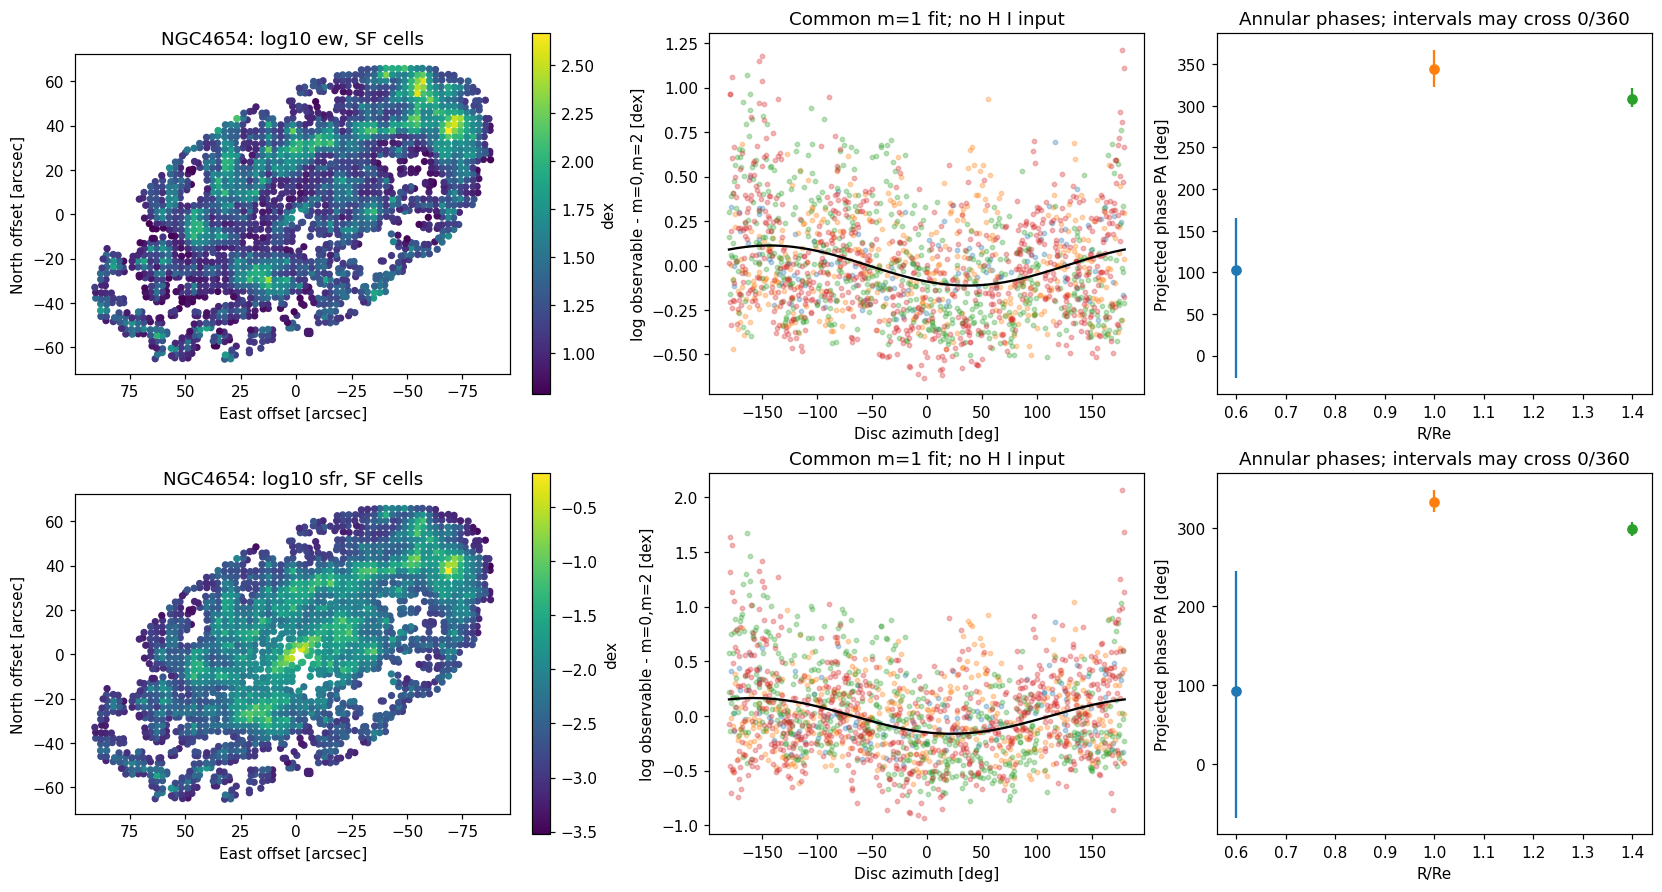

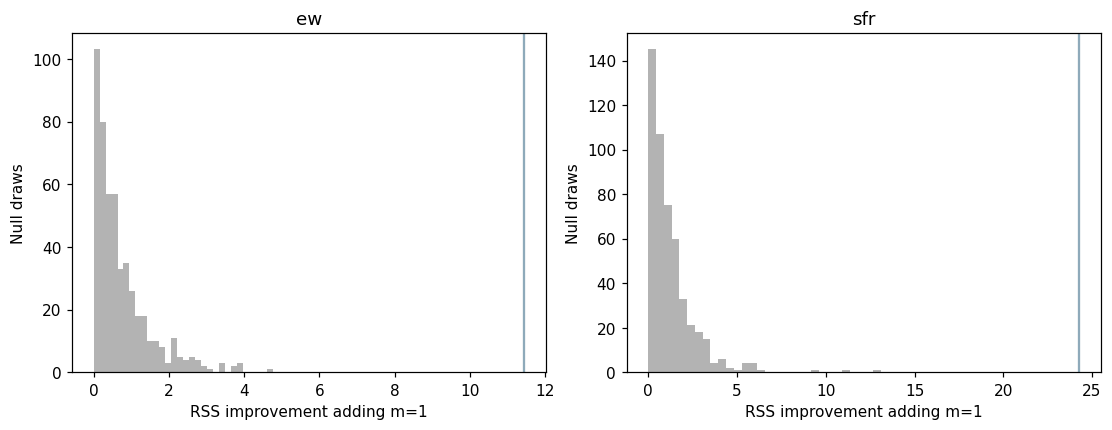

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), layout='constrained')
for j, value in enumerate(('ew','sfr')):
    r = target_results[value]
    f = r['frame']
    a = axes[j,0]
    sc = a.scatter(f.east, f.north, c=f[value], s=14, cmap='viridis')
    a.set_aspect('equal'); a.invert_xaxis()
    a.set(xlabel='East offset [arcsec]', ylabel='North offset [arcsec]', title=f'{TARGET}: log10 {value}, SF cells')
    fig.colorbar(sc, ax=a, label='dex')
    a = axes[j,1]
    # Subtract only the annular intercept/radial trend, retain harmonic structure.
    phi_grid = np.linspace(-np.pi, np.pi, 200)
    for ann, z in f.groupby('annulus'):
        indices = z.index.to_numpy()
        base = matvec(r['X'][indices,:-2],r['beta'][:-2])
        # Explicitly remove the fitted m=2 too for display of coherent m=1.
        a.scatter(np.rad2deg(z.phi), z[value]-base, s=8, alpha=.3)
    a.plot(np.rad2deg(phi_grid), r['beta'][-2]*np.cos(phi_grid)+r['beta'][-1]*np.sin(phi_grid), color='black')
    a.set(xlabel='Disc azimuth [deg]', ylabel='log observable - m=0,m=2 [dex]', title='Common m=1 fit; no H I input')
    a = axes[j,2]
    z = annular_summary.loc[annular_summary.observable.eq(value) & annular_summary.A1_dex.notna()]
    for t in z.itertuples():
        centre=(R_EDGES[int(t.annulus)]+R_EDGES[int(t.annulus)+1])/2
        a.errorbar(centre, t.PA_sky_deg,
            yerr=np.array([[max(0,-t.PA_offset_lo)], [max(0,t.PA_offset_hi)]]), fmt='o')
    a.set(xlabel='R/Re', ylabel='Projected phase PA [deg]', title='Annular phases; intervals may cross 0/360')
plt.show()

fig, axes = plt.subplots(1,2,figsize=(10,3.8),layout='constrained')
for a, value in zip(axes, ('ew','sfr')):
    r=target_results[value]
    a.hist(r['null'], bins=30, color='0.7')
    a.axvline(r['summary']['RSS_gain'], color=galaxy_colors[TARGET])
    a.set(xlabel='RSS improvement adding m=1', ylabel='Null draws', title=value)
plt.show()


## 4. Pre-peak population benchmark

Apply the identical coherent Fourier fit to available single-centre pre-peak
galaxies. Report the empirical exceedance rank (1 + controls >= target)/(N + 1).
This small, heterogeneous control sample is a descriptive comparison, not a
matched population p-value. Cells are not independent control galaxies.
The common radial grid and angular gates can leave different usable annuli;
the table explicitly reports each set, and differences limit comparability.


,status,GALID,observable,cells,clusters,annuli,A1_dex,A1_lo,A1_hi,phi_disc_deg,PA_sky_deg,PA_offset_lo,PA_offset_hi,phase_resultant,RSS_gain,p_wild,p_mc_se,failed_boot,condition
0,ok,NGC4189,ew,581.0,83.0,"1,2,3",0.061815,0.023450,0.128106,24.778869,89.216847,-58.521353,60.151526,0.861751,1.141465,0.05,0.021794,0.0,13.085081
1,ok,NGC4189,sfr,581.0,83.0,"1,2,3",0.091320,0.030203,0.182601,30.980933,94.387970,-31.105805,63.690390,0.904252,2.491654,0.05,0.021794,0.0,13.085081
2,ok,NGC4254,ew,1633.0,220.0,"0,1,2,3",0.122195,0.087398,0.157874,63.168209,120.278712,-20.631010,19.418158,0.986913,11.948621,0.01,0.009950,0.0,29.376930
3,ok,NGC4254,sfr,1633.0,220.0,"0,1,2,3",0.135653,0.097065,0.187884,59.443661,116.134012,-20.224495,33.423373,0.973160,14.604601,0.01,0.009950,0.0,29.376930
4,ok,NGC4294,ew,339.0,57.0,"1,2,3",0.174449,0.116609,0.272215,153.775343,321.600380,-9.496782,8.025188,0.982889,5.019545,0.01,0.009950,0.0,14.963529
5,ok,NGC4294,sfr,339.0,57.0,"1,2,3",0.162985,0.092309,0.262857,147.016016,318.696079,-18.391687,11.854168,0.968456,4.328968,0.01,0.009950,0.0,14.963529
6,ok,NGC4321,ew,3250.0,515.0,"0,1,2",0.054956,0.027504,0.078788,127.658830,232.081896,-27.625198,19.770921,0.977955,3.841098,0.01,0.009950,0.0,23.449854
7,ok,NGC4321,sfr,3250.0,515.0,"0,1,2",0.061348,0.027572,0.103862,128.951774,233.406855,-30.652791,30.017642,0.956271,4.802806,0.03,0.017059,0.0,23.449854
8,ok,NGC4351,ew,220.0,35.0,"0,1,2",0.140488,0.098063,0.215374,12.261626,79.472984,-20.346911,20.163664,0.969423,2.011053,0.01,0.009950,0.0,19.861027
9,ok,NGC4351,sfr,220.0,35.0,"0,1,2",0.130605,0.077214,0.209555,16.238653,82.290093,-26.969892,32.154208,0.933740,1.718783,0.01,0.009950,0.0,19.861027


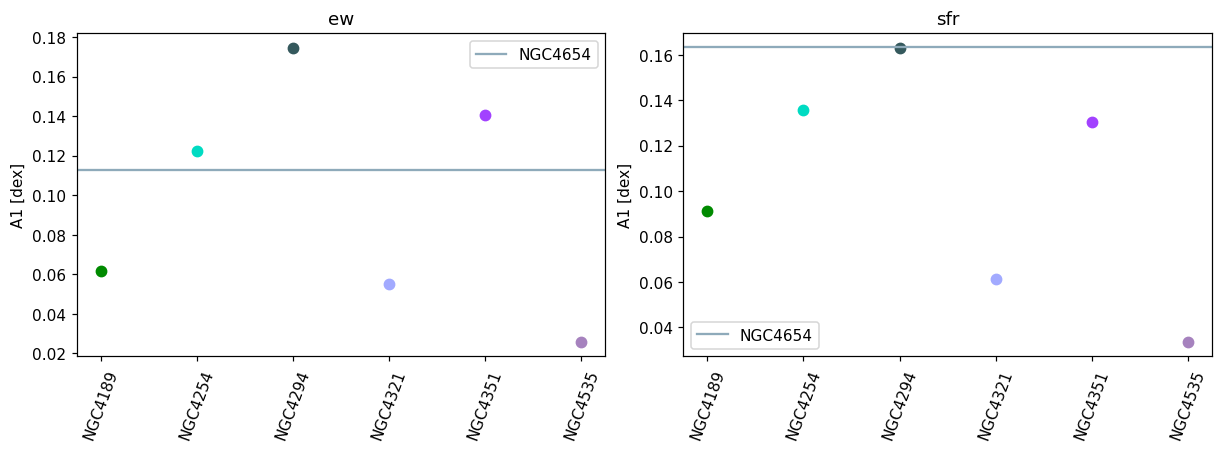

,observable,N_control,empirical_exceedance_rank
0,ew,6,0.571429
1,sfr,6,0.142857


In [7]:
controls = sorted(g for g, f in samples.items() if f.stage.iloc[0] == 'pre-peak' and g != TARGET)
population_rows = []
for j, galid in enumerate(controls):
    for k, value in enumerate(('ew','sfr')):
        try:
            r = fourier_analysis(samples[galid], value, SEED+200+2*j+k, nboot=99, nnull=99)
            population_rows.append(dict(status='ok', **r['summary']))
        except ValueError as exc:
            population_rows.append(dict(GALID=galid, observable=value, status=str(exc)))
population = pd.DataFrame(population_rows)
display(population)
population_ranks = []
fig, axes = plt.subplots(1,2,figsize=(11,4),layout='constrained')
for ax, value in zip(axes,('ew','sfr')):
    z = population.loc[population.observable.eq(value) & population.status.eq('ok')]
    target_amp = target_results[value]['summary']['A1_dex']
    rank = (1+np.sum(z.A1_dex>=target_amp))/(len(z)+1) if len(z) else np.nan
    population_ranks.append(dict(observable=value, N_control=len(z), empirical_exceedance_rank=rank))
    for i, row in enumerate(z.itertuples()):
        ax.scatter(i,row.A1_dex,color=galaxy_colors[row.GALID],s=45)
    ax.axhline(target_amp,color=galaxy_colors[TARGET],label=TARGET)
    ax.set(xticks=np.arange(len(z)),xticklabels=z.GALID.tolist(),ylabel='A1 [dex]',title=value)
    ax.tick_params(axis='x',rotation=70);ax.legend()
plt.show()
display(pd.DataFrame(population_ranks))


## 5. Frozen external pre-peak predictor and transfer diagnostics

Predict log SFR from additive cubic splines of local log stellar density and
R/Re plus linear global log stellar mass. Knot locations (four quantiles),
ridge alpha=1 and all fitting choices are fixed before target evaluation.
Each control galaxy has total weight 1, regardless of its cell count. The target
does not enter spline fitting, ridge fitting, scaling, or support determination.
See [SplineTransformer documentation](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.SplineTransformer.html).

Leave-one-control-galaxy-out residuals quantify transfer biases. Target
predictions require interpolation within the 3D convex hull of control
covariates (mass density, radius, global mass) and a nearby control cell in
standardized covariates. Outside support stays NaN. The reference is conditional
on the surviving-SF selection and may not capture all morphological/confounding
differences. The pre-peak label is an environmental control selection, not H I
direction information. At least three usable control galaxies are required.


In [8]:
FEATURES = ['star','r','global_mass']
REFERENCE_ALPHA = 1.0
REFERENCE_MAX_NEIGHBOUR_DISTANCE = 1.0

def fit_ridge_checked(design,y,weights):
    y=np.asarray(y,dtype=float)
    assert np.isfinite(design).all() and np.isfinite(y).all()
    # The installed BLAS emits matmul warnings even for finite correct output.
    # Scope the filter to fitting, then independently check its normal equations.
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore',message=r'(divide by zero|overflow|invalid value) encountered in matmul',category=RuntimeWarning)
        model=Ridge(alpha=REFERENCE_ALPHA).fit(design,y,sample_weight=weights)
    centre=np.average(design,axis=0,weights=weights)
    yc=y-np.average(y,weights=weights)
    xc=design-centre
    gram=np.einsum('ni,n,nj->ij',xc,weights,xc)
    gram.flat[::gram.shape[0]+1]+=REFERENCE_ALPHA
    rhs=np.einsum('ni,n,n->i',xc,weights,yc)
    independent=np.linalg.solve(gram,rhs)
    assert np.isfinite(model.coef_).all()
    np.testing.assert_allclose(model.coef_,independent,rtol=1e-6,atol=1e-8)
    return model

class FrozenReference:
    def __init__(self, frame, galaxy_multiplicity=None):
        self.frame = frame
        self.galaxies = sorted(frame.GALID.unique())
        assert TARGET not in self.galaxies
        x = frame[FEATURES].to_numpy()
        self.centre = x.mean(axis=0)
        self.scale = x.std(axis=0)
        if np.any(self.scale <= 0): raise ValueError('Reference covariate has zero range')
        xs = (x-self.centre)/self.scale
        self.hull = Delaunay(xs)
        self.tree = cKDTree(xs)
        self.splines = SplineTransformer(n_knots=4, degree=3, include_bias=False, knots='quantile')
        spline = self.splines.fit_transform(x[:,:2])
        design = np.column_stack([spline, xs[:,2]])
        self.design = design
        counts = frame.groupby('GALID').GALID.transform('size').to_numpy()
        weights = 1/counts
        if galaxy_multiplicity is not None:
            weights *= frame.GALID.map(galaxy_multiplicity).fillna(0).to_numpy()
        weights *= len(weights)/weights.sum()
        self.model = fit_ridge_checked(design,frame.sfr,weights)
    def predict(self, frame, model=None):
        x=frame[FEATURES].to_numpy()
        xs=(x-self.centre)/self.scale
        design=np.column_stack([self.splines.transform(x[:,:2]), xs[:,2]])
        model=self.model if model is None else model
        pred=matvec(design,model.coef_)+model.intercept_
        support=(self.hull.find_simplex(xs)>=0) & (self.tree.query(xs)[0] <= REFERENCE_MAX_NEIGHBOUR_DISTANCE)
        return np.where(support,pred,np.nan)
    def bootstrap_predict(self, frame, multiplicity):
        # Conditional-design galaxy bootstrap: retain the frozen spline basis,
        # covariate scaling and baseline support, resample galaxy fit weights.
        counts=self.frame.groupby('GALID').GALID.transform('size').to_numpy()
        weights=self.frame.GALID.map(multiplicity).fillna(0).to_numpy()/counts
        weights*=len(weights)/weights.sum()
        model=fit_ridge_checked(self.design,self.frame.sfr,weights)
        return self.predict(frame,model)

if len(controls)<3: raise RuntimeError('Need >=3 usable pre-peak galaxies')
reference_cells = pd.concat([samples[g] for g in controls],ignore_index=True)
reference_cells = reference_cells.loc[np.isfinite(reference_cells[FEATURES+['sfr']]).all(axis=1)].copy()
reference = FrozenReference(reference_cells)
assert TARGET not in set(reference_cells.GALID)
logo_rows=[]
for g in controls:
    train=reference_cells.loc[reference_cells.GALID.ne(g)]
    test=reference_cells.loc[reference_cells.GALID.eq(g)]
    try:
        pred=FrozenReference(train).predict(test)
        delta=test.sfr.to_numpy()-pred
        good=np.isfinite(delta)
        logo_rows.append(dict(GALID=g,N_supported=int(good.sum()),fraction_supported=good.mean(),
            mean_residual=np.mean(delta[good]) if good.any() else np.nan,
            RMSE=np.sqrt(np.mean(delta[good]**2)) if good.any() else np.nan,status='ok'))
    except (ValueError,QhullError) as exc:
        logo_rows.append(dict(GALID=g,status=str(exc)))
logo=pd.DataFrame(logo_rows)
display(logo)
target_confirmation=samples[TARGET].copy()
target_confirmation['pred_sfr']=reference.predict(target_confirmation)
target_confirmation['delta']=target_confirmation.sfr-target_confirmation.pred_sfr
print('Supported target cells:',target_confirmation.delta.notna().sum(),'/',len(target_confirmation))
if target_confirmation.delta.notna().sum()<MIN_CELLS_ANNULUS:
    raise RuntimeError('Too few in-support target cells for enhancement; do not extrapolate.')


Supported target cells: 1697 / 1803


,GALID,N_supported,fraction_supported,mean_residual,RMSE,status
0,NGC4189,532,0.882255,0.020473,0.336487,ok
1,NGC4254,1613,0.987753,0.178923,0.443782,ok
2,NGC4294,311,0.859116,0.302714,0.440618,ok
3,NGC4321,0,0.000000,NaN,NaN,ok
4,NGC4351,0,0.000000,NaN,NaN,ok
5,NGC4383,0,0.000000,NaN,NaN,ok
6,NGC4535,1444,0.992440,-0.321995,0.505949,ok


## 6. Spatial discovery/confirmation split and absolute enhancement

Use log EW as the fixed primary localization observable. Randomly split whole
bin-aware clusters once (seed fixed): discovery estimates the common phase;
confirmation cells within one coarse-cell side of any discovery cell centre
are additionally discarded to reduce PSF leakage. The held-out phase is not
optimized for the residual values. All confirmation cells on either disc
hemisphere must also have supported external predictions. Tests refer to the
mean residual of supported held-out coarse cells, not all target pixels.

Resample confirmation clusters and resample whole control galaxies by fitting
new reference coefficients to their multiplicity weights. The covariate design,
spline basis, scaling and baseline support stay frozen: the interval is
conditional on those choices and does not cover knot-selection uncertainty.
The basic interval uses the bootstrap displacement
about the fixed-reference estimate; a centred bootstrap upper-tail test targets
H0: mean delta on the discovery-positive side <=0. This is approximate inference
conditional on the discovery phase. Phase uncertainty is assessed by repeated
splits; their overlapping estimates are sensitivity results, **not** independent
tests and their spread is not a confidence interval. Report side+ absolute
residual and side+ minus side- separately. Joint reference uncertainty,
measurement systematics, covariate transfer and remaining spatial dependence
limit causal/physical interpretation.


In [9]:
def split_discovery_confirmation(frame, seed):
    rng=np.random.default_rng(seed)
    clusters=np.array(sorted(frame.cluster.unique()))
    discovery_ids=set(rng.choice(clusters,len(clusters)//2,replace=False))
    disc=frame.loc[frame.cluster.isin(discovery_ids)].copy()
    confirm=frame.loc[~frame.cluster.isin(discovery_ids)].copy()
    dist=cKDTree(disc[['east','north']]).query(confirm[['east','north']])[0]
    confirm=confirm.loc[dist>=CELL_ARCSEC].copy()
    assert not set(disc.cluster)&set(confirm.cluster)
    return disc,confirm

def discover_phase(disc):
    f=supported_frame(disc,'ew')
    if f.cluster.nunique()<MIN_CLUSTERS: raise ValueError('Discovery has too few clusters')
    b=fit_beta(fourier_design(f),f.ew)
    return phase_amplitude(b)[1]

def side_means(confirm, phase, weights=None):
    d=confirm.delta.to_numpy()
    side=np.cos(confirm.phi.to_numpy()-phase)>=0
    if weights is None: weights=np.ones(len(confirm))
    out=[]
    for take in (side,~side):
        ok=take & np.isfinite(d) & (weights>0)
        if ok.sum()<10 or confirm.loc[ok].cluster.nunique()<5:
            raise ValueError('Insufficient supported cells/clusters in hemisphere')
        out.append(np.average(d[ok],weights=weights[ok]))
    return np.array([out[0],out[1],out[0]-out[1]])

discovery,confirmation=split_discovery_confirmation(target_confirmation,SEED+1000)
discovery_phase=discover_phase(discovery)
confirmation['positive_side']=np.cos(confirmation.phi-discovery_phase)>=0
point=side_means(confirmation,discovery_phase)
print('Discovery phase (sky PA):',sky_pa(TARGET,discovery_phase))
print('Discovery / buffered confirmation cells:',len(discovery),len(confirmation))
print('Supported confirmation by hemisphere:',confirmation.loc[confirmation.delta.notna()].groupby('positive_side').size().to_dict())
rng=np.random.default_rng(SEED+1001)
reference_boot=[]
failed_reference_boot=0
for _ in range(N_REFERENCE_BOOT):
    gs=rng.choice(controls,len(controls),replace=True)
    mult=pd.Series(gs).value_counts().to_dict()
    try:
        z=confirmation.copy()
        z['delta']=z.sfr-reference.bootstrap_predict(z,mult)
        # Keep the exact original supported confirmation population; reject draws
        # whose resampled reference loses that support, rather than changing estimand.
        original_support=confirmation.delta.notna().to_numpy()
        if z.loc[original_support,'delta'].isna().any():
            raise ValueError('Resampled reference lost fixed target support')
        z.loc[~original_support,'delta']=np.nan
        reference_boot.append(side_means(z,discovery_phase,cluster_weights(z.cluster,rng)))
    except (ValueError,QhullError): failed_reference_boot+=1
reference_boot=np.asarray(reference_boot)
valid_reference_fraction=len(reference_boot)/N_REFERENCE_BOOT
print('Valid joint-reference/confirmation draws:',len(reference_boot),'/',N_REFERENCE_BOOT)
enhancement_inference_valid=valid_reference_fraction>=.9
if len(reference_boot)>=20:
    displacement=reference_boot-point
    ci_low=point-np.quantile(displacement,.975,axis=0)
    ci_high=point-np.quantile(displacement,.025,axis=0)
    p_positive=(1+np.sum(displacement[:,0]>=point[0]))/(len(displacement)+1)
else:
    ci_low=ci_high=np.full(3,np.nan);p_positive=np.nan
enhancement_summary=pd.DataFrame(dict(statistic=['positive-side absolute delta','negative-side absolute delta','positive minus negative'],
    estimate_dex=point,CI95_low=ci_low,CI95_high=ci_high))
if not enhancement_inference_valid:
    enhancement_summary[['CI95_low','CI95_high']]=np.nan
    p_positive=np.nan
    print('Reference support unstable under galaxy resampling: no formal enhancement inference.')
display(enhancement_summary)
print('One-sided absolute enhancement p (conditional / approximate):',p_positive)
split_rows=[]
for j in range(N_SPLITS):
    try:
        d,c=split_discovery_confirmation(target_confirmation,SEED+1100+j)
        phase=discover_phase(d)
        s=side_means(c,phase)
        split_rows.append(dict(split=j,PA_sky=sky_pa(TARGET,phase),positive=s[0],negative=s[1],contrast=s[2],status='ok'))
    except ValueError as exc:
        split_rows.append(dict(split=j,status=str(exc)))
split_sensitivity=pd.DataFrame(split_rows)
display(split_sensitivity)


Discovery phase (sky PA): 312.9631020108873
Discovery / buffered confirmation cells: 905 778
Supported confirmation by hemisphere: {False: 292, True: 437}
Valid joint-reference/confirmation draws: 299 / 299
One-sided absolute enhancement p (conditional / approximate): 0.22333333333333333


,statistic,estimate_dex,CI95_low,CI95_high
0,positive-side absolute delta,0.099946,-0.120093,0.248577
1,negative-side absolute delta,-0.003432,-0.253267,0.149537
2,positive minus negative,0.103378,-0.019586,0.223149


,split,PA_sky,positive,negative,contrast,status
0,0,319.288357,0.087918,-0.018953,0.106871,ok
1,1,318.528073,0.082177,0.017998,0.064179,ok
2,2,320.085466,0.121097,-0.025254,0.146352,ok
3,3,321.236366,0.042563,0.013715,0.028848,ok
4,4,311.883387,0.128099,-0.001446,0.129545,ok
5,5,328.923623,0.122060,0.003066,0.118994,ok
6,6,323.978750,0.070075,0.051161,0.018914,ok
7,7,318.352780,0.127573,0.013852,0.113720,ok
8,8,324.394220,0.082420,-0.000934,0.083353,ok
9,9,309.045394,0.049794,0.046191,0.003603,ok


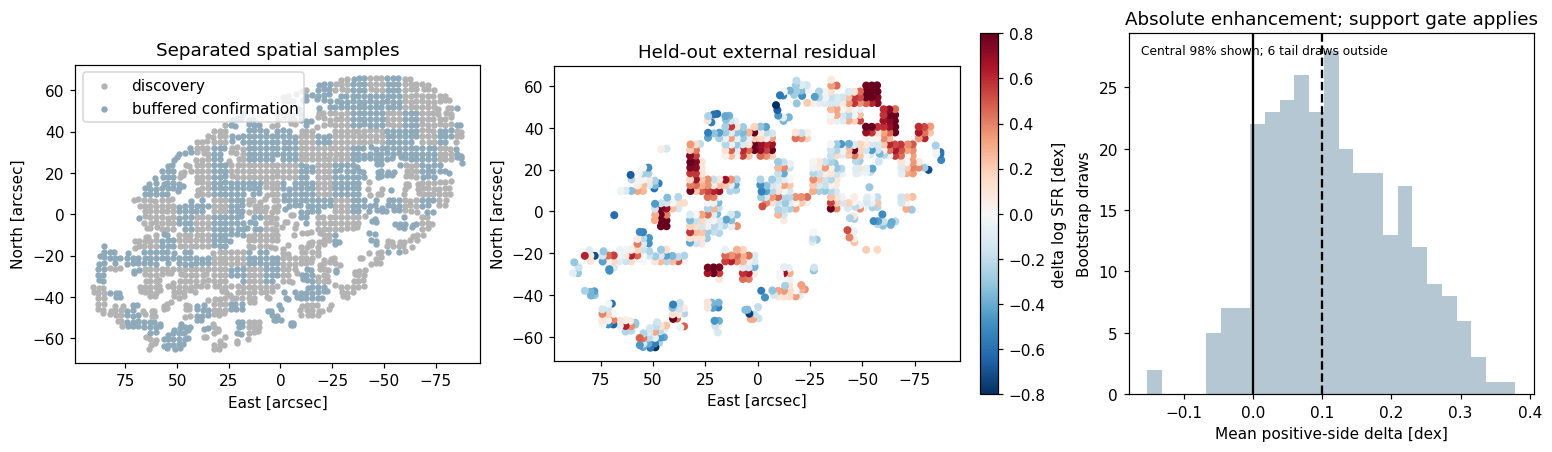

In [10]:
fig,axes=plt.subplots(1,3,figsize=(14,4),layout='constrained')
for f,label,color in ((discovery,'discovery','0.7'),(confirmation,'buffered confirmation',galaxy_colors[TARGET])):
    axes[0].scatter(f.east,f.north,s=10,label=label,color=color)
axes[0].invert_xaxis();axes[0].set_aspect('equal');axes[0].legend()
axes[0].set(xlabel='East [arcsec]',ylabel='North [arcsec]',title='Separated spatial samples')
f=confirmation.loc[confirmation.delta.notna()]
sc=axes[1].scatter(f.east,f.north,c=f.delta,cmap='RdBu_r',vmin=-.8,vmax=.8,s=18)
axes[1].invert_xaxis();axes[1].set_aspect('equal')
axes[1].set(xlabel='East [arcsec]',ylabel='North [arcsec]',title='Held-out external residual')
fig.colorbar(sc,ax=axes[1],label='delta log SFR [dex]')
if len(reference_boot):
    lo,hi=np.quantile(reference_boot[:,0],[.01,.99])
    axes[2].hist(reference_boot[:,0],bins=np.linspace(min(lo,-.02),max(hi,.02),26),color=galaxy_colors[TARGET],alpha=.65)
    tails=np.sum((reference_boot[:,0]<lo)|(reference_boot[:,0]>hi))
    axes[2].text(.03,.97,f'Central 98% shown; {tails} tail draws outside',transform=axes[2].transAxes,va='top',fontsize=8)
axes[2].axvline(0,color='black');axes[2].axvline(point[0],color='black',ls='--')
axes[2].set(xlabel='Mean positive-side delta [dex]',ylabel='Bootstrap draws',title='Absolute enhancement; support gate applies')
plt.show()


## 7. Underlying stellar-structure control and scale sensitivity

Fit the stellar mass density with the identical Fourier basis and coverage
gates on (a) exactly the SF-cell support, with SF clusters, and (b) the full
usable stellar footprint with stellar-bin-aware clusters. The first allows a
matched-footprint comparison but remains conditional on SF selection; the
second measures broader stellar structure. A1 across different log observables
is comparable in dex but is not by itself a causal discriminator.

Double cell and block sides as a resolution/correlation sensitivity check.
These are descriptive alternative fits, not extra primary discoveries.


In [11]:
star_rows=[]
for j,(label,frame) in enumerate((('SF matched footprint',target_results['ew']['frame']),
                                ('full usable footprint',stellar_samples[TARGET]))):
    try:
        r=fourier_analysis(frame,'star',SEED+2000+j,nboot=199,nnull=199)
        star_rows.append(dict(footprint=label,status='ok',**r['summary']))
    except ValueError as exc:
        star_rows.append(dict(footprint=label,status=str(exc)))
stellar_summary=pd.DataFrame(star_rows)
display(stellar_summary)
coarse,_,coarse_info=aggregate_maps(target_row,target_maps,CELL_ARCSEC*2,BLOCK_ARCSEC*2)
scale_rows=[]
for j,value in enumerate(('ew','sfr')):
    try:
        r=fourier_analysis(coarse,value,SEED+2100+j,nboot=199,nnull=199)
        scale_rows.append(dict(cell_arcsec=CELL_ARCSEC*2,block_arcsec=BLOCK_ARCSEC*2,status='ok',**r['summary']))
    except ValueError as exc:
        scale_rows.append(dict(observable=value,status=str(exc)))
scale_summary=pd.DataFrame(scale_rows)
display(scale_summary)


,footprint,status,GALID,observable,cells,clusters,annuli,A1_dex,A1_lo,A1_hi,phi_disc_deg,PA_sky_deg,PA_offset_lo,PA_offset_hi,phase_resultant,RSS_gain,p_wild,p_mc_se,failed_boot,condition
0,SF matched footprint,ok,NGC4654,star,1803,249,"0,1,2,3",0.038528,0.021064,0.057676,234.591564,335.942651,-22.032443,45.188845,0.965387,1.322359,0.005,0.004987,0,29.938242
1,full usable footprint,ok,NGC4654,star,2106,259,"0,1,2,3",0.044765,0.028664,0.059447,244.096484,346.702361,-20.886247,49.334129,0.976997,2.111557,0.005,0.004987,0,29.845784


,cell_arcsec,block_arcsec,status,GALID,observable,cells,clusters,annuli,A1_dex,A1_lo,A1_hi,phi_disc_deg,PA_sky_deg,PA_offset_lo,PA_offset_hi,phase_resultant,RSS_gain,p_wild,p_mc_se,failed_boot,condition
0,5.6,16.8,ok,NGC4654,ew,503,70,"0,1,2,3",0.114959,0.056347,0.192700,214.854996,319.745478,-14.334351,30.811282,0.967973,3.340654,0.005,0.004987,3,30.628585
1,5.6,16.8,ok,NGC4654,sfr,503,70,"0,1,2,3",0.168932,0.093076,0.282603,200.162607,310.716434,-11.228443,11.237768,0.985549,7.177902,0.005,0.004987,2,30.628585


## 8. H I geometry is introduced only here

NGC4654's inherited VIVA label is NW compression, represented by sky PA 315 deg.
This is a coarse compass label from the previous notebook, not a newly measured
H I PA with a formal uncertainty. We report directed separation from each MUSE
phase without computing an alignment p-value or adopting a +/-45 deg pass rule.
If the Fourier phase is not detected/concentrated its numerical separation is
not evidence of agreement. A real H I uncertainty model remains future work.

The fixed-direction supplementary fit uses cos(sky_PA_i - 315 deg), radial
terms and disc m=2 terms. Its coefficient interval is a clustered bootstrap
description. Given the already known galaxy and geometry this is a physical
consistency check, not a newly preregistered confirmatory experiment.
Alignment and a positive SF residual cannot alone establish RPS causation or
exclude tides; gas compression/CO information would supply additional evidence.


In [12]:
HI_SKY_PA_DEG=315.0
HI_SOURCE='Inherited NGC4654 NW compression label from 20260914_check_SF_gradient_scan_VIVA.ipynb'
print(HI_SOURCE)
alignment_rows=[]
for row in primary_summary.itertuples():
    separation=abs((row.PA_sky_deg-HI_SKY_PA_DEG+180)%360-180)
    alignment_rows.append(dict(observable=row.observable,PA_SF=row.PA_sky_deg,
        PA_HI_compass=HI_SKY_PA_DEG,separation_deg=separation,
        detected_conditional=row.detected_conditional,HI_uncertainty='not measured'))
display(pd.DataFrame(alignment_rows))
fixed_direction_rows=[]
for j,value in enumerate(('ew','sfr')):
    f=target_results[value]['frame']
    pa=np.deg2rad(sky_pa(TARGET,f.phi.to_numpy()))
    direction=np.cos(pa-np.deg2rad(HI_SKY_PA_DEG))
    X=np.column_stack([fourier_design(f,False),direction])
    b=fit_beta(X,f[value])
    rng=np.random.default_rng(SEED+3000+j)
    draws=[]
    for _ in range(N_BOOT):
        try: draws.append(fit_beta(X,f[value],cluster_weights(f.cluster,rng))[-1])
        except ValueError: pass
    if len(draws)<.9*N_BOOT: raise ValueError('Unstable fixed-direction bootstrap')
    fixed_direction_rows.append(dict(observable=value,beta_HI_dex=b[-1],
        CI95_lo=np.quantile(draws,.025),CI95_hi=np.quantile(draws,.975)))
display(pd.DataFrame(fixed_direction_rows))


Inherited NGC4654 NW compression label from 20260914_check_SF_gradient_scan_VIVA.ipynb


,observable,PA_SF,PA_HI_compass,separation_deg,detected_conditional,HI_uncertainty
0,ew,321.205871,315.0,6.205871,True,not measured
1,sfr,312.078875,315.0,2.921125,True,not measured


,observable,beta_HI_dex,CI95_lo,CI95_hi
0,ew,0.082099,0.048343,0.120306
1,sfr,0.133932,0.092239,0.182654


## 9. Reproducibility checks and evidence-led reading

Final assertions check target exclusion from the reference, mask provenance,
non-overlapping discovery/confirmation clusters and finite primary inference.
This notebook prints numerical conclusions from the live run. It does not
replace uncertain results with the historical gradient PA or a desired answer.
No blanket enhancement/RPS claim is made from asymmetry alone.


In [13]:
assert TARGET not in reference.galaxies
assert set(reference_cells.GALID)==set(controls)
assert not set(discovery.cluster)&set(confirmation.cluster)
assert (target_maps['sf_mask'] & ~target_maps['valid_disc_mask']).sum()==0
assert np.isfinite(primary_summary[['A1_dex','PA_sky_deg','p_wild','p_Holm']]).all().all()
assert primary_summary.p_wild.between(0,1).all()
assert primary_summary.p_Holm.ge(primary_summary.p_wild).all()
for value,r in target_results.items():
    assert r['frame'].cluster.nunique()>=MIN_CLUSTERS
    assert r['summary']['cells']==len(r['frame'])
detected=primary_summary.loc[primary_summary.detected_conditional,'observable'].tolist()
print('Detected coherent m=1 observables at adopted scale (Holm, conditional):',detected or 'none')
print('Held-out positive-side absolute residual:',round(float(point[0]),4),'dex')
if enhancement_inference_valid and np.isfinite(p_positive):
    print('Approximate positive-enhancement test p:',round(float(p_positive),4))
    print('Positive enhancement supported by this test:',bool(point[0]>0 and p_positive<=ALPHA))
else:
    print('Absolute enhancement inference unresolved: reference resampling/support gate failed.')
print('Inspect transfer residuals, phase intervals, stellar control and coarse-scale fit before interpretation.')
print('H I is a coarse comparison only; RPS causation remains unestablished by this notebook alone.')
print('CHECKS_OK; Python',platform.python_version())


Detected coherent m=1 observables at adopted scale (Holm, conditional): ['ew', 'sfr']
Held-out positive-side absolute residual: 0.0999 dex
Approximate positive-enhancement test p: 0.2233
Positive enhancement supported by this test: False
Inspect transfer residuals, phase intervals, stellar control and coarse-scale fit before interpretation.
H I is a coarse comparison only; RPS causation remains unestablished by this notebook alone.
CHECKS_OK; Python 3.13.3
